In [1]:
#import giggle_my_version as giggle
import numpy as np 
import matplotlib.pyplot as plt

import math
#from scipy import ndimage as ndimage
#import disk_ecc_spiral as disk
#import disk_ecc as kevindisk
#import disk_ecc_spiral_pp as proto
#from astropy import units as u
#from astropy.constants import G, sigma_sb, k_B, m_p
from astropy.io import fits
import bettermoments as bm
import matplotlib.gridspec as gridspec


from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales
import cmcrameri.cm as cmc
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import cmocean
#from scipy.interpolate import LinearNDInterpolator as interpnd

In [2]:
path = 'resid_2017.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

In [3]:
resid_fits = fits.open('resid_2017_M0.fits')
resid_image = resid_fits['PRIMARY'].data

In [4]:
wcs = WCS(resid_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = resid_fits['PRIMARY'].header

In [5]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   70                                                  
NAXIS2  =                   70                                                  
BMAJ    =   0.0001675649722318                                                  
BMIN    =   0.0001154586725963                                                  
BPA     =       89.03882598877                                                  
BUNIT   = 'Jy/beam m/s'                                                         
CTYPE1  = 'RA---SIN'                                                            
CRVAL1  =       23.65779056704                                                  
CDELT1  =  -2.777777948778E-05                                                  
CRPIX1  =                 36

In [6]:
def wcs_extent(image, wcs):
    nx, ny = image.shape
    cx, cy = nx / 2.0, ny / 2.0
    ctr = wcs.pixel_to_world(cx, cy)
    ra_ctr = ctr.ra
    dec_ctr = ctr.dec
    left = wcs.pixel_to_world(0, cy).ra
    right = wcs.pixel_to_world(nx - 1, cy).ra
    bot = wcs.pixel_to_world(cx, 0).dec
    top = wcs.pixel_to_world(cx, ny - 1).dec
    ra_scale = np.cos(dec_ctr.rad) * 3600.0
    return [
        (left - ra_ctr).deg * ra_scale,
        (right - ra_ctr).deg * ra_scale,
        (bot - dec_ctr).deg * 3600.0,
        (top - dec_ctr).deg * 3600.0,
    ]

In [7]:
parallax = 17.4725e-3
dist = 1/parallax

scalelength = 100*u.au.to(u.parsec)
theta = scalelength/dist
theta_rad = theta*u.rad.to(u.deg)

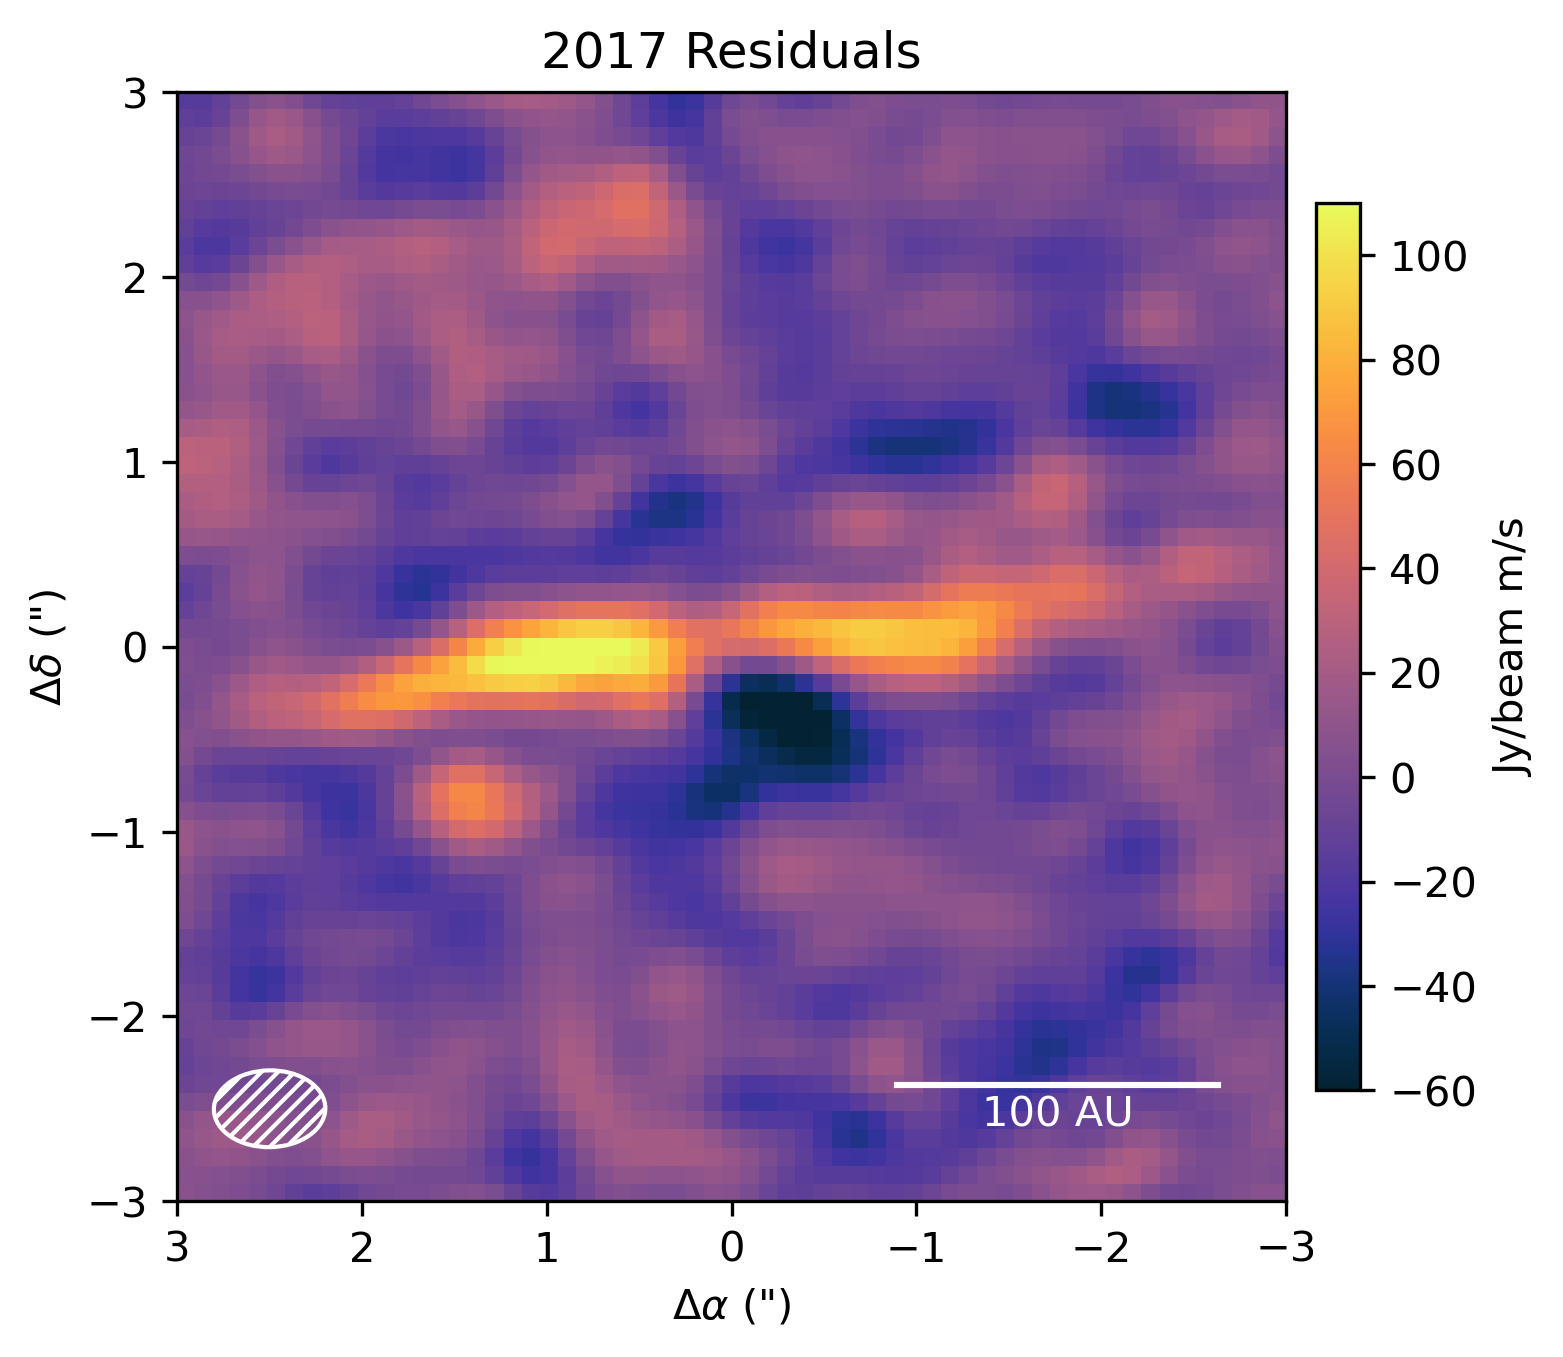

In [8]:
extent_data = wcs_extent(resid_image, wcs)

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

fig, ax = plt.subplots(dpi=300)

#ax = fig.add_subplot(gs[0, i])
#ax.set_aspect('equal')
im = plt.imshow(resid_image, cmap=cmocean.cm.thermal, origin="lower",extent=extent_data, vmin=-60, vmax=110)
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, label="Jy/beam m/s")

distance_pc = dist
physical_size_au = 100
distance_au = distance_pc * 206265  # 1 pc = 206265 AU
theta_arcsec = (physical_size_au / distance_au) * 206265
scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)
ax.add_artist(scalebar)
beam = Ellipse((2.5, -2.5), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
ax.add_patch(beam)
ax.set_xlabel(r'$\Delta\alpha$ (")')
ax.set_ylabel(r'$\Delta\delta$ (")')

plt.title("2017 Residuals")

plt.savefig("2017_resids.png")
#plt.title(title, fontsize=18)
#ax.set_xlabel("RA offset (arcsec)")
#ax.set_ylabel("Dec offset (arcsec)")

In [17]:
resid_fits_new = fits.open('../dmr_plots/49Ceti_resid_map_4-18_M0.fits')
resid_image_new = resid_fits_new['PRIMARY'].data

data_fits  = fits.open('../dmr_plots/12CO_LSRK_cleanimage_M0.fits')
data_image  = data_fits["PRIMARY"].data

In [18]:
path = '../dmr_plots/49Ceti_resid_map_4-18.fits'
rms = bm.estimate_RMS(data=data, N=1)
data, velax = bm.load_cube(path)
threshold_mask = bm.get_threshold_mask(data=data,
                                       clip=0.001,
                                       smooth_threshold_mask=0.0)
masked_data = threshold_mask*data
m0 = bm.collapse_zeroth(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

In [19]:
#resid_fits_new = fits.open('../dmr_plots/49Ceti_model_map_4-18_M0.fits')
#resid_image_new = resid_fits_new['PRIMARY'].data

In [31]:
wcs_new = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header_new = data_fits['PRIMARY'].header

In [21]:
path = '../dmr_plots/49Ceti_resid_map_4-18.fits'
rms = bm.estimate_RMS(data=data, N=1)
data, velax = bm.load_cube(path)
threshold_mask = bm.get_threshold_mask(data=data,
                                       clip=3,
                                       smooth_threshold_mask=0.0)
masked_data = threshold_mask*data
m1 = bm.collapse_first(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=m1, method='first', path=path)

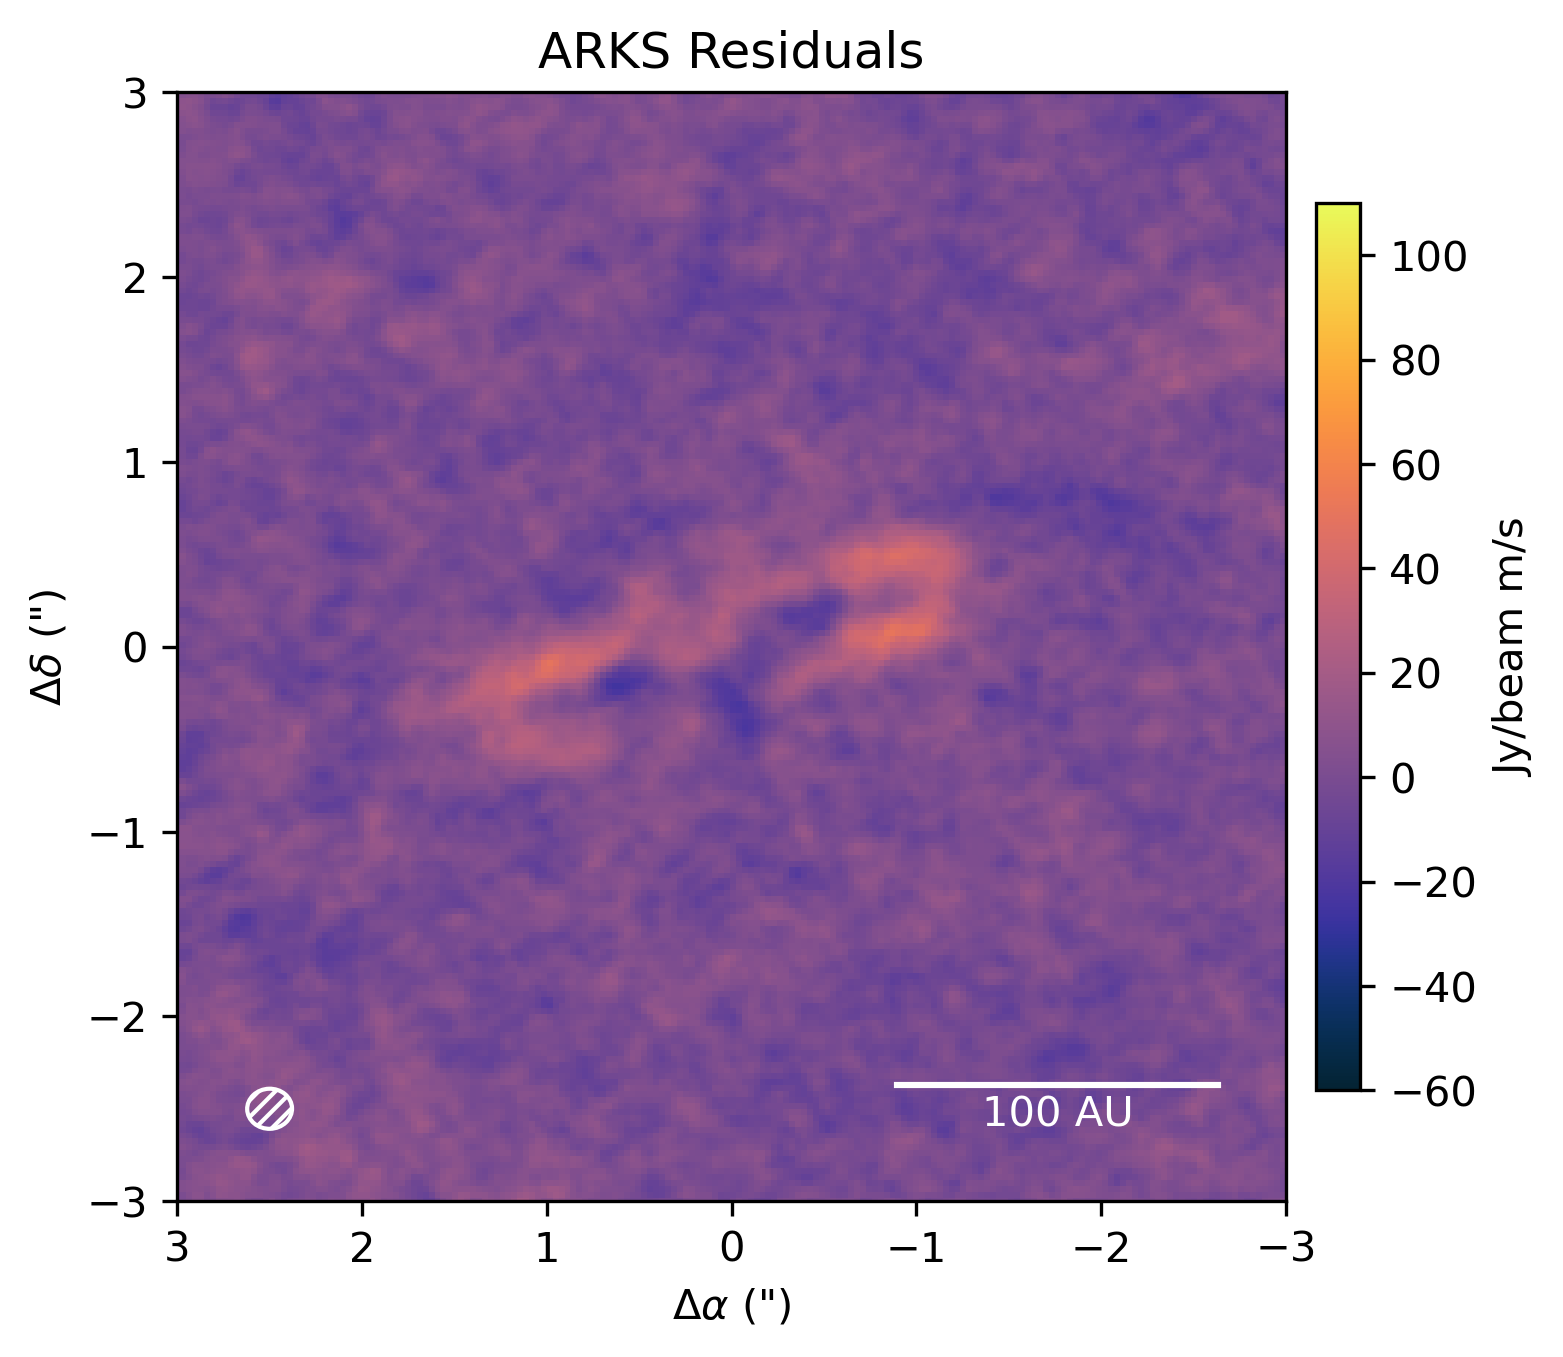

In [22]:


extent_data_new = wcs_extent(data_image, wcs_new)

# Beam parameters from header (in degrees)
bmaj_deg = header_new['BMAJ']  # Major axis
bmin_deg = header_new['BMIN']  # Minor axis
bpa_deg  = header_new['BPA']   # Position angle

bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

fig, ax = plt.subplots(dpi=300)

#ax = fig.add_subplot(gs[0, i])
#ax.set_aspect('equal')
#im = plt.imshow(resid_image_new, cmap=cmocean.cm.thermal, origin="lower",extent=extent_data_new, vmin=-60, vmax=110)
im = plt.imshow(resid_image_new, cmap=cmocean.cm.thermal, origin="lower",extent=extent_data_new, vmin=-60, vmax=110)
#ax.set_xlim(-3.5, 3.5)
#ax.set_ylim(-3.5, 3.5)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, label="Jy/beam m/s")

distance_pc = dist
physical_size_au = 100
distance_au = distance_pc * 206265  # 1 pc = 206265 AU
theta_arcsec = (physical_size_au / distance_au) * 206265
scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)
ax.add_artist(scalebar)
beam = Ellipse((2.5, -2.5), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)
ax.add_patch(beam)
ax.set_xlabel(r'$\Delta\alpha$ (")')
ax.set_ylabel(r'$\Delta\delta$ (")')

plt.title("ARKS Residuals")

plt.savefig("arks_m0_resids.png")
#plt.title(title, fontsize=18)
#ax.set_xlabel("RA offset (arcsec)")
#ax.set_ylabel("Dec offset (arcsec)")

In [29]:
resid_fits_new = fits.open('../dmr_plots/49Ceti_resid_map_4-18_M1.fits')
resid_image_new = resid_fits_new['PRIMARY'].data

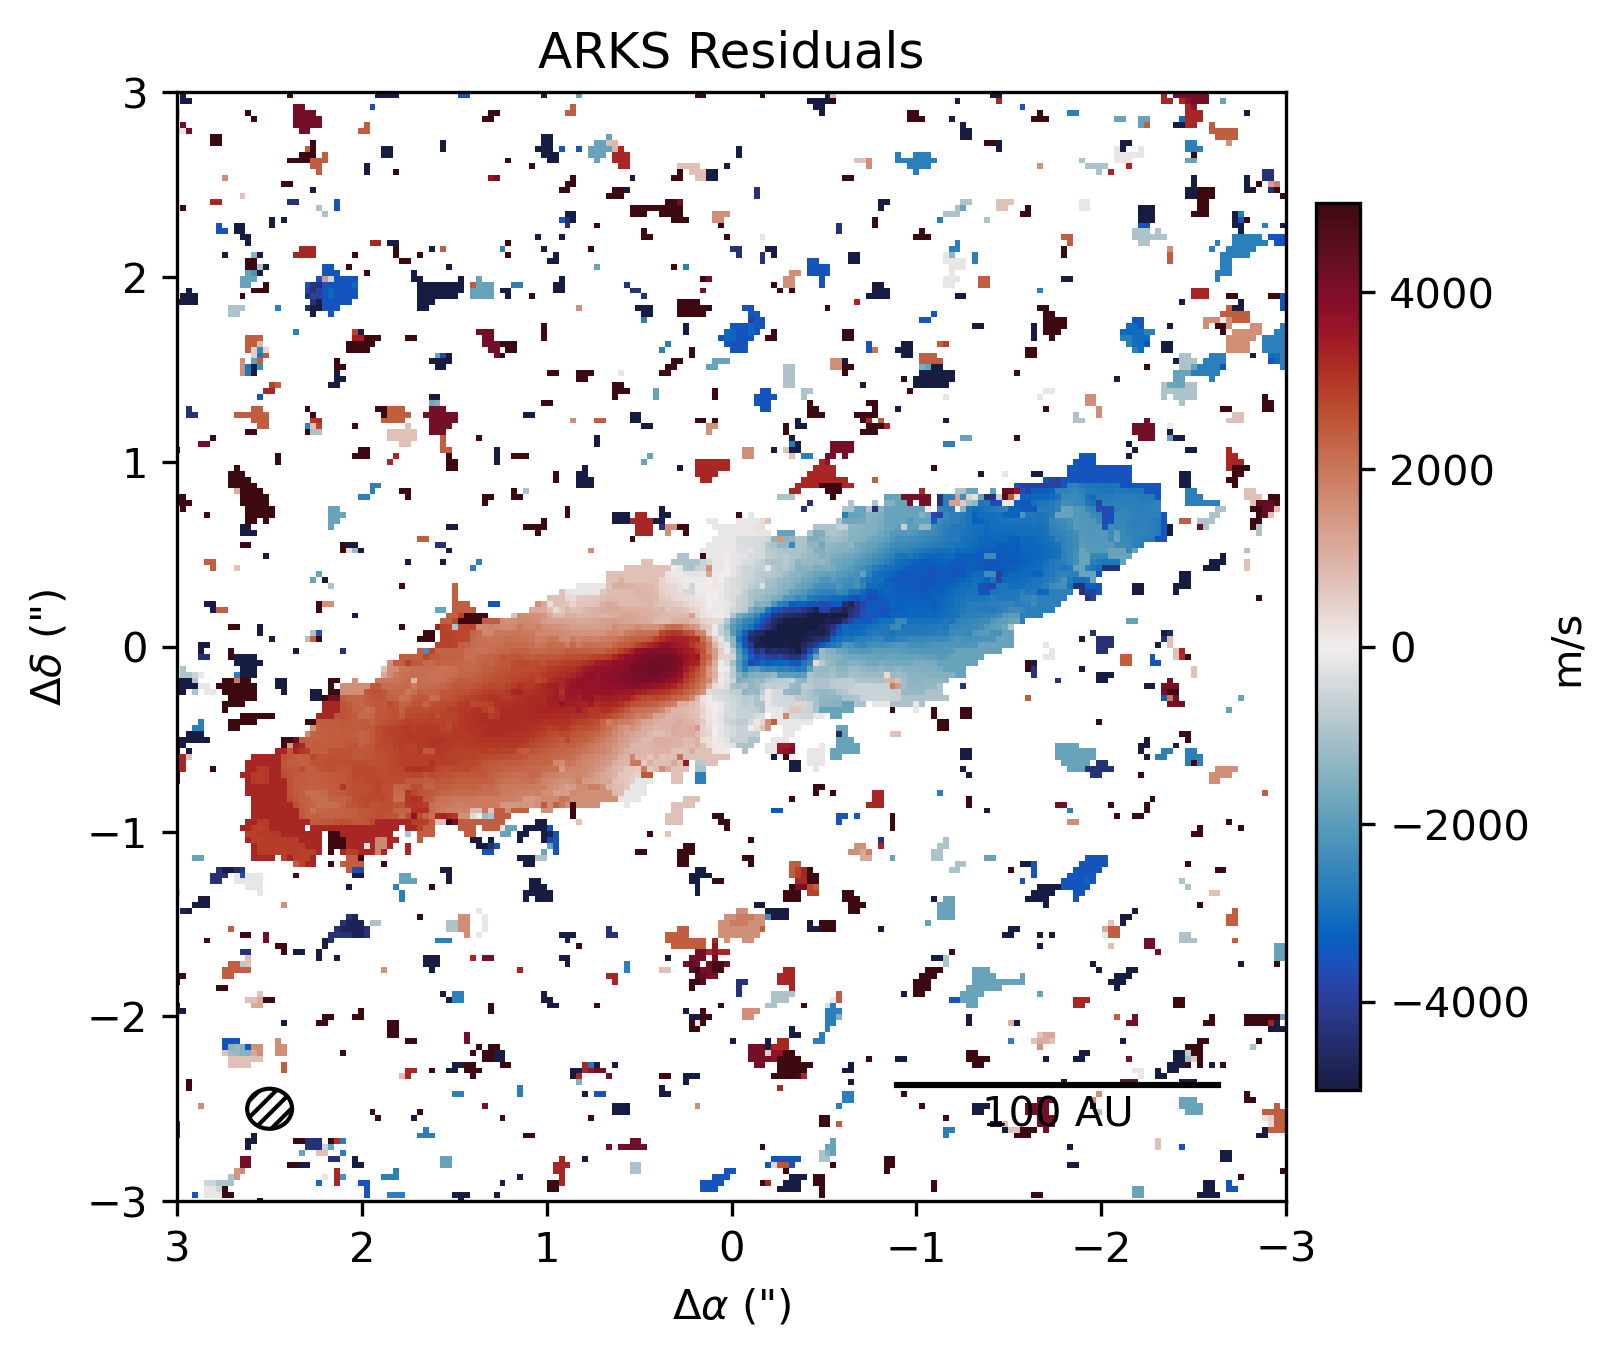

In [32]:

extent_data_new = wcs_extent(data_image, wcs_new)

# Beam parameters from header (in degrees)
bmaj_deg = header_new['BMAJ']  # Major axis
bmin_deg = header_new['BMIN']  # Minor axis
bpa_deg  = header_new['BPA']   # Position angle

bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

fig, ax = plt.subplots(dpi=300)

#ax = fig.add_subplot(gs[0, i])
#ax.set_aspect('equal')
#im = plt.imshow(resid_image_new, cmap=cmocean.cm.thermal, origin="lower",extent=extent_data_new, vmin=-60, vmax=110)
im = plt.imshow(resid_image_new-2700, cmap=cmocean.cm.balance, origin="lower",extent=extent_data_new,vmin=-5000, vmax=5000)
#ax.set_xlim(-3.5, 3.5)
#ax.set_ylim(-3.5, 3.5)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, label="m/s")

distance_pc = dist
physical_size_au = 100
distance_au = distance_pc * 206265  # 1 pc = 206265 AU
theta_arcsec = (physical_size_au / distance_au) * 206265
scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='black', frameon=False, 
                            size_vertical=0.01)
ax.add_artist(scalebar)
beam = Ellipse((2.5, -2.5), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="black", linewidth=1)
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)
ax.add_patch(beam)
ax.set_xlabel(r'$\Delta\alpha$ (")')
ax.set_ylabel(r'$\Delta\delta$ (")')

plt.title("ARKS Residuals")

plt.savefig("arks_m1_3sigma_resids.png")
#plt.title(title, fontsize=18)
#ax.set_xlabel("RA offset (arcsec)")
#ax.set_ylabel("Dec offset (arcsec)")

In [25]:
path = 'resid_2017.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)

threshold_mask = bm.get_threshold_mask(data=data,
                                       clip=3,
                                       smooth_threshold_mask=0.0)
masked_data = threshold_mask*data
m1 = bm.collapse_first(velax=velax, data=masked_data, rms=rms)
bm.save_to_FITS(moments=m1, method='first', path=path)

In [26]:
resid_lowres_M1 = fits.open('resid_2017_M1.fits')
resid_M1= resid_lowres_M1['PRIMARY'].data

wcs_new = WCS(resid_lowres_M1['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header_new = resid_lowres_M1['PRIMARY'].header

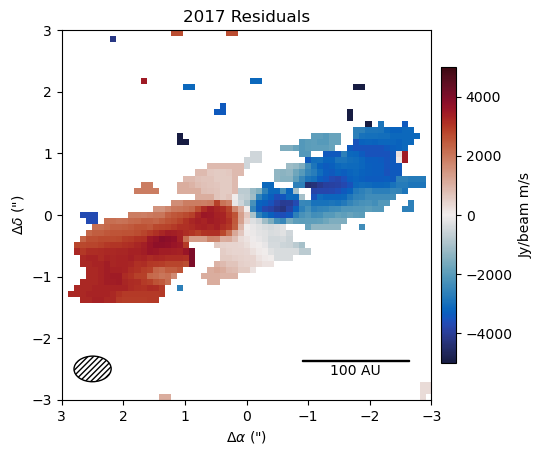

In [27]:
extent_data = wcs_extent(resid_M1, wcs_new)

# Beam parameters from header (in degrees)
bmaj_deg = header_new['BMAJ']  # Major axis
bmin_deg = header_new['BMIN']  # Minor axis
bpa_deg  = header_new['BPA']   # Position angle

bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

fig, ax = plt.subplots()

#ax = fig.add_subplot(gs[0, i])
#ax.set_aspect('equal')
im = plt.imshow(resid_M1-2780, cmap=cmocean.cm.balance, origin="lower",extent=extent_data,vmin=-5000, vmax=5000)
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02, label="Jy/beam m/s")

distance_pc = dist
physical_size_au = 100
distance_au = distance_pc * 206265  # 1 pc = 206265 AU
theta_arcsec = (physical_size_au / distance_au) * 206265
scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='black', frameon=False, 
                            size_vertical=0.01)
ax.add_artist(scalebar)
beam = Ellipse((2.5, -2.5), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="black", linewidth=1)
ax.add_patch(beam)
ax.set_xlabel(r'$\Delta\alpha$ (")')
ax.set_ylabel(r'$\Delta\delta$ (")')

plt.title("2017 Residuals")

plt.savefig("2017_resids_M1.png")
#plt.title(title, fontsize=18)
#ax.set_xlabel("RA offset (arcsec)")
#ax.set_ylabel("Dec offset (arcsec)")